# 03 -- Statistical Feature Analysis

**Corresponds to:** Manuscript Sec.4.3-4.4 (Feature Importance analysis)

We perform univariate statistical testing (Kolmogorov-Smirnov test, Mann-Whitney U test, Cohen's d) on all 408 regional diffusion metrics to identify which individual features best discriminate between groups. This provides biological interpretability independent of the multivariate neural network.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp, mannwhitneyu
from tqdm import tqdm
import os, warnings
warnings.filterwarnings('ignore')
np.random.seed(41)

DATA_DIR = os.path.join("data")
FIG_DIR = os.path.join("figures", "statistical_analysis")
os.makedirs(FIG_DIR, exist_ok=True)

plt.rcParams.update({
    'font.family': 'DejaVu Sans Mono', 'font.size': 12,
    'axes.titlesize': 14, 'axes.labelsize': 12
})
COLORS = ['#9671bd', '#77b5b6', '#e08c6c', '#7e7e7e']

## 1. Analysis Function

In [2]:
def analyze_features(df, diag_col, group1_label, group2_label, output_prefix):
    """Run KS test, Mann-Whitney, and Cohen's d for all features."""
    input_features = [c for c in df.columns if c.startswith("harm_")]

    mask1 = df[diag_col] == group1_label
    mask2 = df[diag_col] == group2_label

    results = []
    for feat in tqdm(input_features, desc=f"Analyzing {output_prefix}"):
        g1 = df.loc[mask1, feat].dropna().values
        g2 = df.loc[mask2, feat].dropna().values
        if len(g1) < 10 or len(g2) < 10:
            continue

        ks_stat, ks_p = ks_2samp(g1, g2)
        mw_stat, mw_p = mannwhitneyu(g1, g2, alternative='two-sided')

        pooled_std = np.sqrt((np.std(g1)**2 + np.std(g2)**2) / 2)
        cohens_d = abs(np.mean(g1) - np.mean(g2)) / pooled_std if pooled_std > 0 else 0

        results.append({
            'feature': feat.replace("harm_", ""),
            'ks_stat': ks_stat, 'ks_pval': ks_p,
            'mw_pval': mw_p, 'cohens_d': cohens_d,
            f'{group1_label}_mean': np.mean(g1),
            f'{group2_label}_mean': np.mean(g2),
            f'{group1_label}_std': np.std(g1),
            f'{group2_label}_std': np.std(g2)
        })

    results_df = pd.DataFrame(results)
    results_df['-log10_ks_p'] = -np.log10(results_df['ks_pval'].clip(lower=1e-300))
    results_df = results_df.sort_values('ks_stat', ascending=False).reset_index(drop=True)

    return results_df

## 2. Patient vs Control Analysis

In [3]:
df = pd.read_pickle(os.path.join(DATA_DIR, "data_full.pkl"))
print(f"Total samples: {len(df)}")

results_pvc = analyze_features(df, 'diag_pvc', 'Patient', 'Control', 'PvC')
print(f"\nTop 10 features (Patient vs Control):")
print(results_pvc[['feature', 'ks_stat', 'ks_pval', 'cohens_d']].head(10).to_string(index=False))

Total samples: 1267


Analyzing PvC:   0%|          | 0/413 [00:00<?, ?it/s]

Analyzing PvC:   5%|▍         | 20/413 [00:00<00:02, 188.01it/s]

Analyzing PvC:   9%|▉         | 39/413 [00:00<00:02, 174.52it/s]

Analyzing PvC:  14%|█▍        | 57/413 [00:00<00:02, 166.25it/s]

...

Analyzing PvC:  92%|█████████▏| 378/413 [00:02<00:00, 119.44it/s]

Analyzing PvC:  95%|█████████▌| 394/413 [00:02<00:00, 130.16it/s]

Analyzing PvC: 100%|█████████▉| 411/413 [00:02<00:00, 137.93it/s]

Analyzing PvC: 100%|██████████| 413/413 [00:02<00:00, 142.85it/s]


Top 10 features (Patient vs Control):
                   feature  ks_stat      ks_pval  cohens_d
              rh_cuneus_MD 0.799035 2.859459e-99  2.311222
    lh_inferiorparietal_MK 0.796214 2.481631e-98  2.277365
              rh_cuneus_MK 0.793228 1.780808e-97  2.355857
    lh_superiorparietal_MD 0.789223 3.320425e-96  2.302368
    rh_superiorparietal_MK 0.787665 1.017520e-95  2.370901
    lh_inferiorparietal_MD 0.784922 6.770934e-95  2.239378
 lh_medialorbitofrontal_MD 0.783739 1.491476e-94  2.269775
    lh_superiorparietal_MK 0.783417 1.911466e-94  2.335607
         lh_paracentral_MK 0.780379 1.510978e-93  2.280991
lh_rostralmiddlefrontal_MK 0.778307 5.363797e-93  2.302706


## 3. SCZ vs Non-SCZ Analysis

In [4]:
# Filter to patient-only subset
df_patients = df[df['diag_pvc'] == 'Patient'].copy()
print(f"Patient samples for subtype analysis: {len(df_patients)}")

results_scz = analyze_features(df_patients, 'diag_scz', 'SCZ', 'Non SCZ', 'SCZ')
print(f"\nTop 10 features (SCZ vs Non-SCZ):")
print(results_scz[['feature', 'ks_stat', 'ks_pval', 'cohens_d']].head(10).to_string(index=False))

Patient samples for subtype analysis: 173


Analyzing SCZ:   0%|          | 0/413 [00:00<?, ?it/s]

Analyzing SCZ:   5%|▌         | 21/413 [00:00<00:01, 198.75it/s]

Analyzing SCZ:  10%|▉         | 41/413 [00:00<00:01, 193.60it/s]

Analyzing SCZ:  15%|█▌        | 64/413 [00:00<00:01, 208.69it/s]

...

Analyzing SCZ:  83%|████████▎ | 343/413 [00:01<00:00, 307.93it/s]

Analyzing SCZ:  91%|█████████ | 376/413 [00:01<00:00, 311.45it/s]

Analyzing SCZ:  99%|█████████▉| 408/413 [00:01<00:00, 265.06it/s]

Analyzing SCZ: 100%|██████████| 413/413 [00:01<00:00, 263.57it/s]


Top 10 features (SCZ vs Non-SCZ):
                 feature  ks_stat      ks_pval  cohens_d
            rh_cuneus_MK 0.990291 4.561452e-48  3.860846
rh_posteriorcingulate_MD 0.970874 4.782843e-45  3.293384
            rh_cuneus_MD 0.947434 3.039542e-42  3.386320
rh_posteriorcingulate_MK 0.946879 9.500835e-42  3.414624
  rh_superiorparietal_MK 0.933148 1.778424e-40  3.660981
  rh_superiorparietal_MD 0.922885 7.201390e-39  3.509455
  lh_superiorparietal_MK 0.913731 4.420678e-38  3.174829
  lh_superiorparietal_MD 0.904022 5.949466e-37  2.916060
  rh_inferiorparietal_MK 0.894313 7.189548e-36  2.828292
lh_transversetemporal_MK 0.894313 7.189548e-36  3.059178


## 4. Feature Distribution Plots

For each task, we plot the top 5 most discriminative features with multi-panel distribution comparisons (histograms, KDE, ECDF, box plots, violin plots).

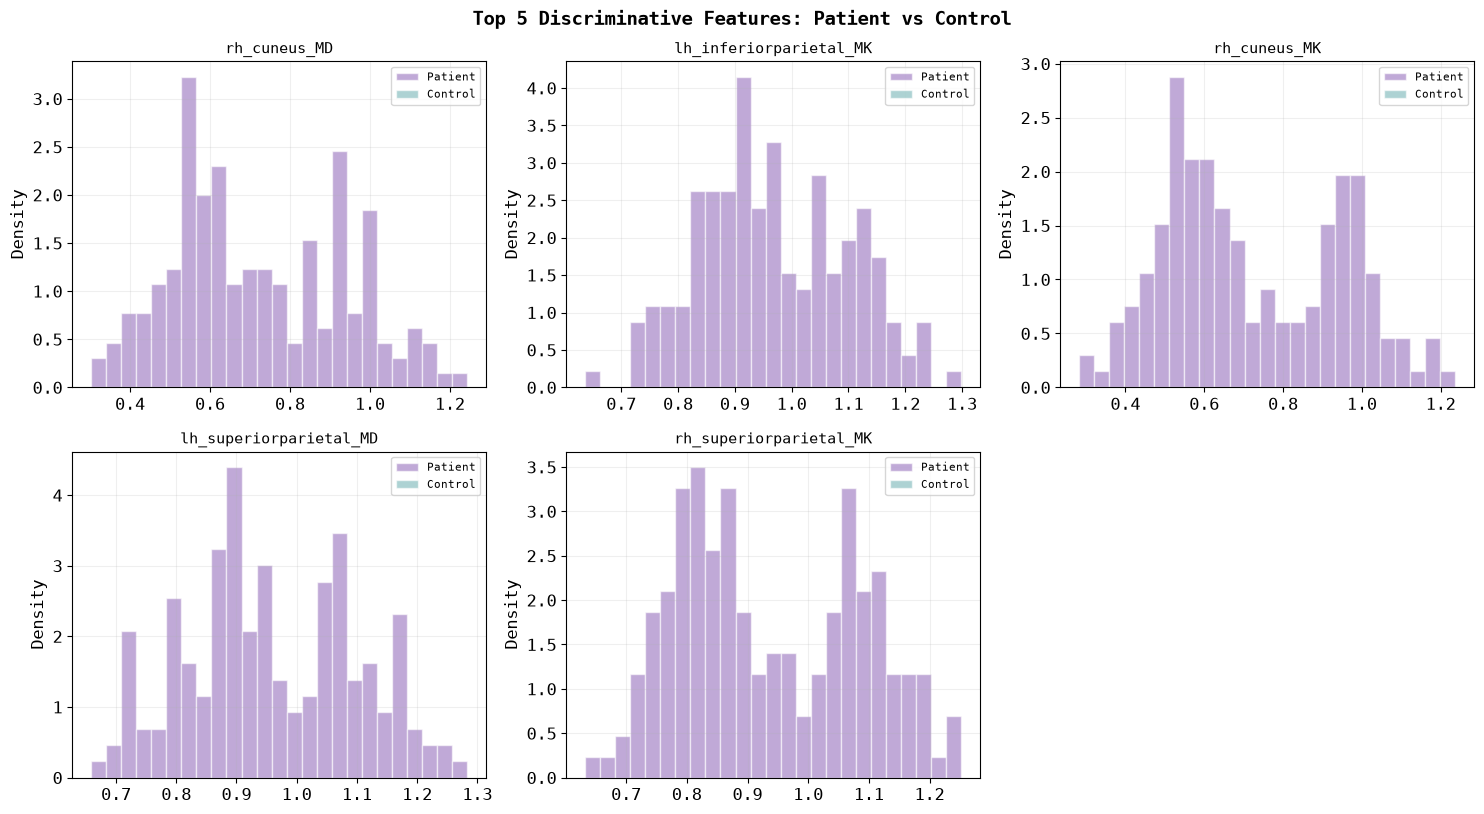

Saved: figures\statistical_analysis\top5_patient_vs_control.png


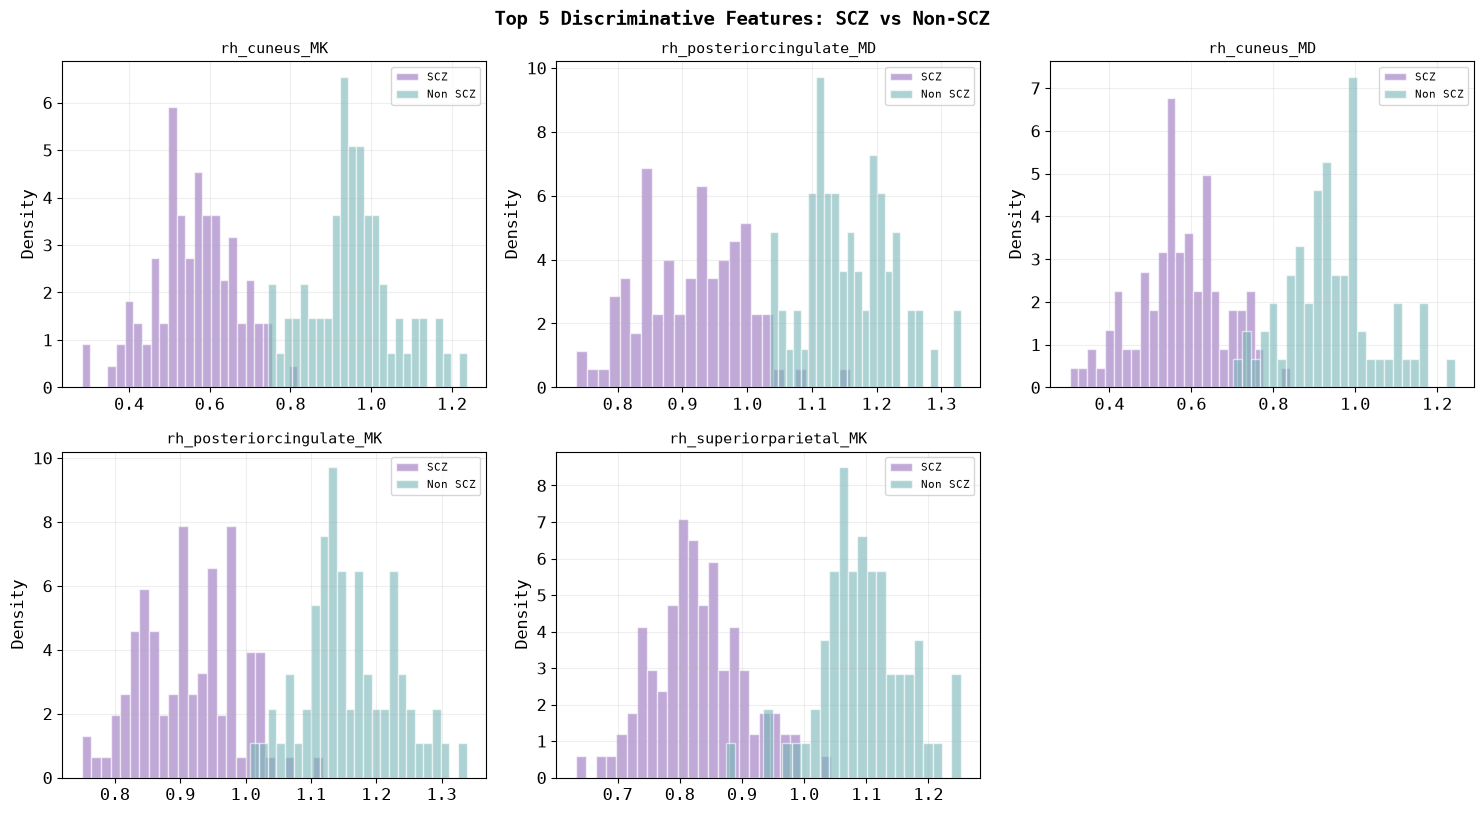

Saved: figures\statistical_analysis\top5_scz_vs_non_scz.png


In [5]:
def plot_top_features(results, group1, group2, title, filename, n=5):
    top5 = results.head(n)
    n_cols = min(3, n)
    n_rows = int(np.ceil(n / n_cols)) + 1  # +1 for stat summary

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes]

    for i, (_, row) in enumerate(top5.iterrows()):
        ax = axes[i]
        feat = f"harm_{row['feature']}"

        g1 = df.loc[df['diag_pvc'] == group1, feat].dropna().values if 'Patient' in group1 else              df_patients.loc[df_patients['diag_scz'] == group1, feat].dropna().values
        g2 = df.loc[df['diag_pvc'] == group2, feat].dropna().values if 'Patient' in group2 else              df_patients.loc[df_patients['diag_scz'] == group2, feat].dropna().values

        ax.hist(g1, bins=25, alpha=0.6, color=COLORS[0], label=group1, density=True, edgecolor='w')
        ax.hist(g2, bins=25, alpha=0.6, color=COLORS[1], label=group2, density=True, edgecolor='w')
        ax.set_title(row['feature'], fontsize=11)
        ax.legend(fontsize=8)
        ax.set_ylabel('Density')
        ax.grid(True, alpha=0.2)

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(title, fontweight='bold', fontsize=14)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename}")

plot_top_features(results_pvc, 'Patient', 'Control',
                  'Top 5 Discriminative Features: Patient vs Control',
                  os.path.join(FIG_DIR, "top5_patient_vs_control.png"))

if len(results_scz) >= 5:
    plot_top_features(results_scz, 'SCZ', 'Non SCZ',
                      'Top 5 Discriminative Features: SCZ vs Non-SCZ',
                      os.path.join(FIG_DIR, "top5_scz_vs_non_scz.png"))

## 5. Save Results Tables

In [6]:
results_pvc.to_csv(os.path.join(FIG_DIR, "feature_analysis_pvc.csv"), index=False)
results_scz.to_csv(os.path.join(FIG_DIR, "feature_analysis_scz.csv"), index=False)

print(f"\nSummary:")
print(f"  Patient vs Control -- features with KS p < 0.05: {(results_pvc['ks_pval'] < 0.05).sum()}/{len(results_pvc)}")
print(f"  SCZ vs Non-SCZ -- features with KS p < 0.05: {(results_scz['ks_pval'] < 0.05).sum()}/{len(results_scz)}")
print(f"  Top PvC feature: {results_pvc.iloc[0]['feature']} (KS={results_pvc.iloc[0]['ks_stat']:.4f})")
print(f"  Top SCZ feature: {results_scz.iloc[0]['feature']} (KS={results_scz.iloc[0]['ks_stat']:.4f})")
print("\n✓ Statistical analysis complete.")


Summary:
  Patient vs Control -- features with KS p < 0.05: 319/413
  SCZ vs Non-SCZ -- features with KS p < 0.05: 300/413
  Top PvC feature: rh_cuneus_MD (KS=0.7990)
  Top SCZ feature: rh_cuneus_MK (KS=0.9903)

✓ Statistical analysis complete.
